In [1]:
"""
2026-02-16 MY 

Check time series of mittalohkot.


"""
import geopandas as gpd
import pandas as pd
import glob
import os
import pickle
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

fpin = '/scratch/project_2008047/Apu-HIKET/results_temp'

# map crop names:
fpkasviDict = '/projappl/project_2008047/Apu-HIKET/helpfuldata/kasviDict.pkl'
# Read in crop type and names:
with open(fpkasviDict, 'rb') as fp:
    kasviDict = pickle.load(fp)


def load_intensities(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f)
    return data

def readTempData(year, fpin):
    metafiles = glob.glob(os.path.join(fpin, 'meta*'))
    mymetafiles = [metafile for metafile in metafiles if str(year) in metafile]

    if mymetafiles:
        #outputfilename = os.path.join(outputpath, 'maxNDVI-' + str(year) + '.csv')

        mydata = []
        for filepath in mymetafiles:

            # Read in meta data:
            data = load_intensities(filepath)
            df = pd.DataFrame(data, columns = ['parcelID', 'Value', 'featureName', 'timeID'])

            #ndvi file:
            filepathndvi = filepath.replace('meta', 'ndvi')
            data2 = load_intensities(filepathndvi)
            df2 = pd.DataFrame(data2, columns = ['parcelID', 'Value', 'featureName', 'timeID'])        

            mydata.append(pd.concat([df, df2], axis = 0))
    return mydata

mydata2023 = readTempData(2023, fpin)

In [36]:
#dfndvi.set_index(['parcelID', 'timeID'])

In [35]:
#dfmeta.set_index(['parcelID', 'timeID'])

In [38]:


def munchData(year, mydata):
    # myParcelIDs:
    parcelpath = '/scratch/project_2008047/Apu-HIKET/shpfiles'
    fieldDataPaths2 = glob.glob(parcelpath + '/fieldData*.csv')
    fieldDataPath2 = [filename for filename in fieldDataPaths2 if str(year) in filename]
    
    df2 = pd.read_csv(fieldDataPath2[0])
    
    myParcelIDs = df2['parcelID']
    
    df = pd.concat(mydata, ignore_index=True)
    df2 = df[df['parcelID'].isin(myParcelIDs)]
    dfmeta = df2[df2['featureName'] == 'meta']
    dfmeta['DOY'] = dfmeta['Value']
    dfmeta['Value'] = pd.to_datetime(dfmeta['DOY'], unit='D', origin = pd.Timestamp(year)).dt.strftime("%Y-%m-%d")
    dfndvi = df2[df2['featureName'] == 'ndvi']
    dfndvi['Crop'] = dfndvi['parcelID'].str.split('_', expand = True)[3]
    merged = dfndvi.merge(dfmeta, on = ['parcelID', 'timeID'], how = 'left')
    merged.rename(columns = {'Value_x': 'maxNDVI', 'Value_y': 'Time'}, inplace = True)
    merged['Crop '] = merged['Crop'].map(kasviDict) 
    #merged2 = merged.set_index('Time').resample('1d').reset_index()
    return merged

merged2023 = munchData('2023', mydata2023)

In [39]:
#merged.set_index('Time').asfreq('D')

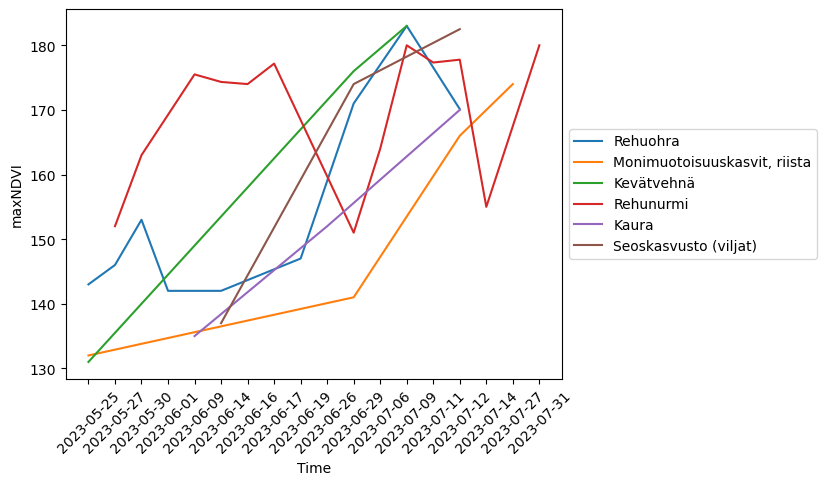

In [40]:

ax = sns.lineplot(data = merged2023.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


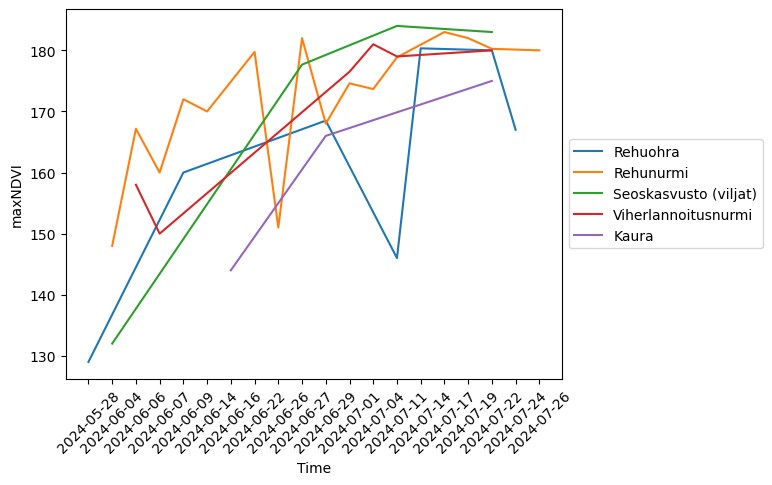

In [43]:
mydata2024 = readTempData(2024, fpin)
merged2024 = munchData('2024', mydata2024)


ax = sns.lineplot(data = merged2024.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


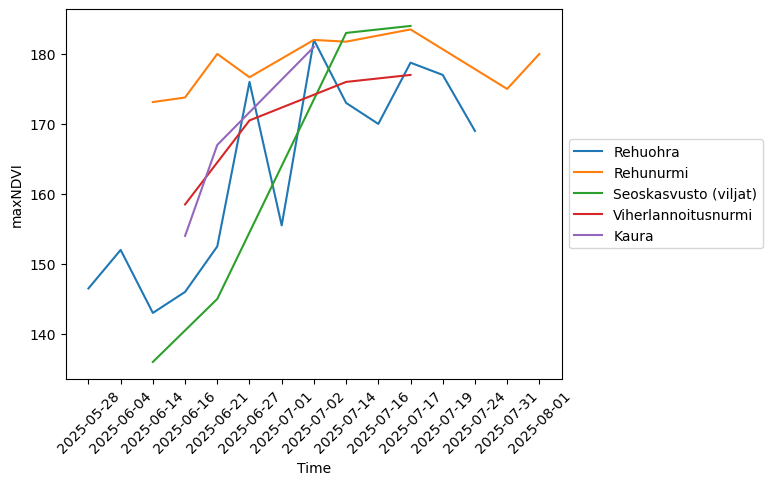

In [48]:
mydata = readTempData(2025, fpin)
merged = munchData('2025', mydata)


ax = sns.lineplot(data = merged.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


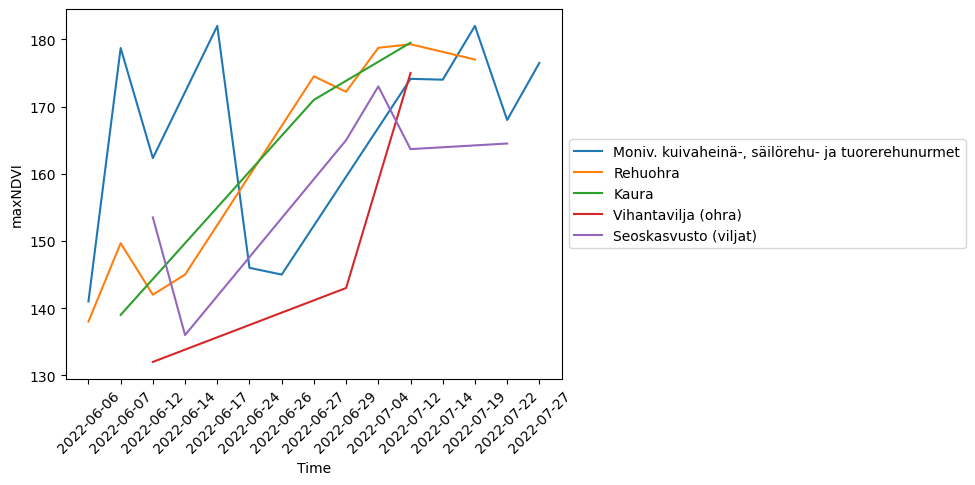

In [47]:
mydata = readTempData(2022, fpin)
merged = munchData('2022', mydata)


ax = sns.lineplot(data = merged.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


### Huom!

## Huom! Vuosissa 2018-2021 päivämäärässä häikkää (mutta ajankohdat kuitenkin välillä 15.5.-31.7.)

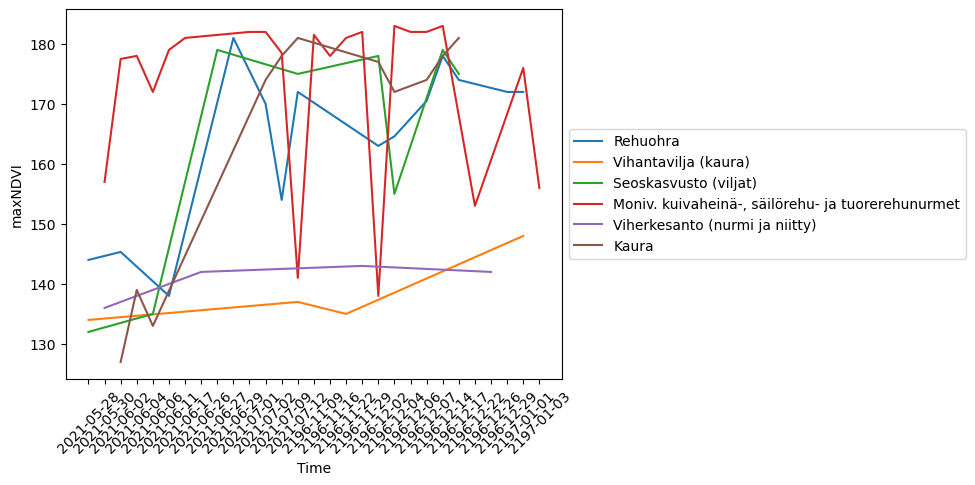

In [56]:
mydata = readTempData(2021, fpin)
merged = munchData('2021', mydata)


ax = sns.lineplot(data = merged.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


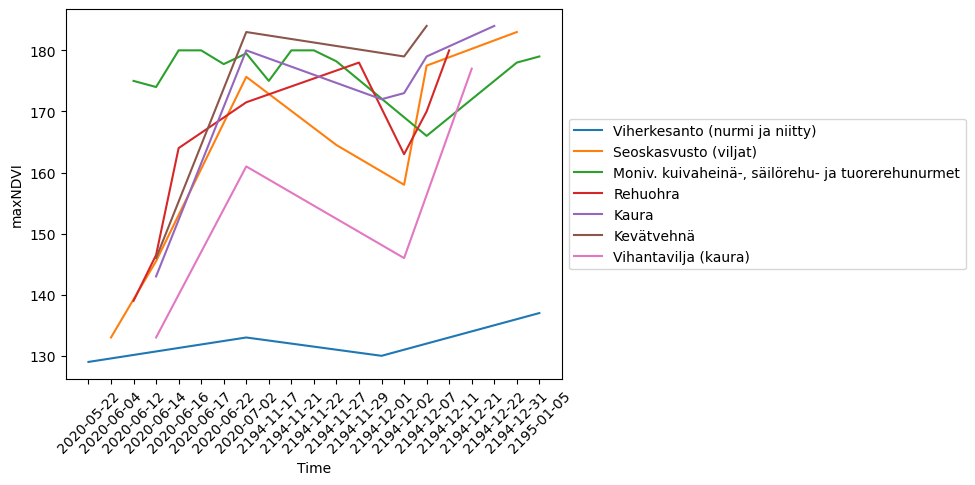

In [50]:
mydata = readTempData(2020, fpin)
merged = munchData('2020', mydata)


ax = sns.lineplot(data = merged.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


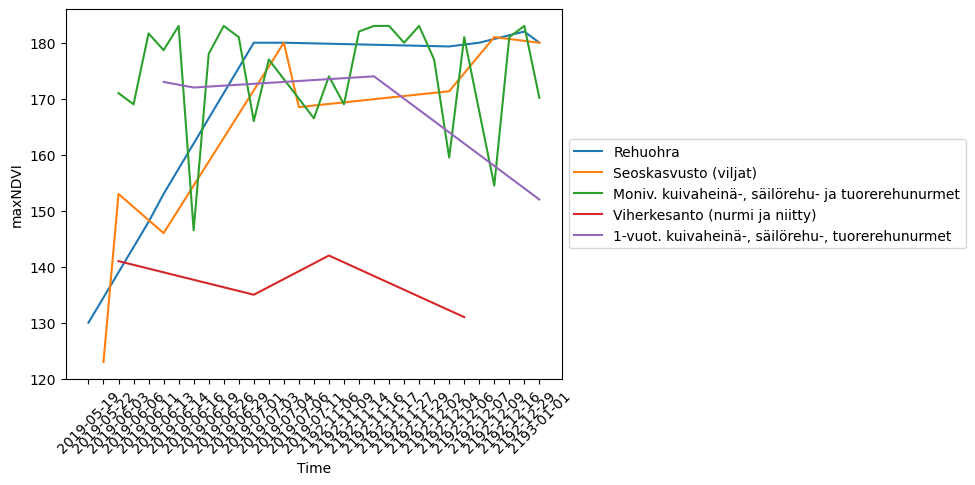

In [51]:
mydata = readTempData(2019, fpin)
merged = munchData('2019', mydata)


ax = sns.lineplot(data = merged.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


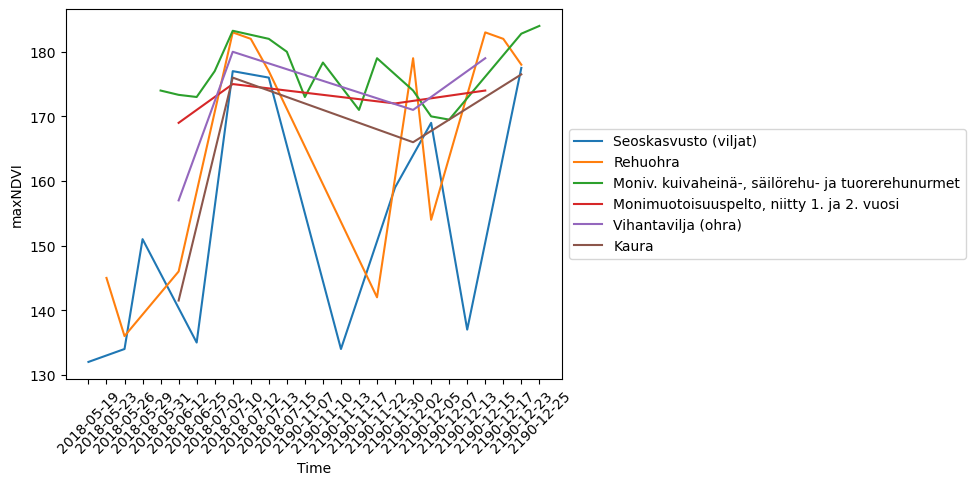

In [52]:
mydata = readTempData(2018, fpin)
merged = munchData('2018', mydata)


ax = sns.lineplot(data = merged.sort_values(by=["Time"]), x = "Time", y = "maxNDVI", hue = 'Crop ', ci = None)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
